In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import pandas_udf, PandasUDFType
from pyspark.sql.types import StructType, StructField, StringType, IntegerType, DoubleType, ArrayType, MapType
import pandas as pd


In [2]:
import sys
import os
import time
# Add the src/ directory to the Python path
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "../src/")))

# testing if we correctly put in module 3 into file ... 

In [3]:
# Check if there's an active Spark context and stop it
from pyspark import SparkContext
if SparkContext._active_spark_context:
    print("Stopping existing Spark context...")
    SparkContext._active_spark_context.stop()
    print("Previous Spark context stopped successfully")

In [4]:
# Set environment variables
os.environ['SPARK_LOCAL_IP'] = '127.0.0.1'

# Create new session with explicit local binding
spark = SparkSession.builder \
    .appName("EEG_Analysis") \
    .config("spark.driver.bindAddress", "127.0.0.1") \
    .config("spark.driver.host", "127.0.0.1") \
    .master("local[*]") \
    .getOrCreate()

print("New Spark session created successfully")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/06 15:01:32 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
25/04/06 15:01:33 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.
25/04/06 15:01:33 WARN Utils: Service 'SparkUI' could not bind on port 4041. Attempting port 4042.
25/04/06 15:01:33 WARN Utils: Service 'SparkUI' could not bind on port 4042. Attempting port 4043.
25/04/06 15:01:33 WARN Utils: Service 'SparkUI' could not bind on port 4043. Attempting port 4044.


New Spark session created successfully


In [5]:
spark = SparkSession.builder.appName("MyApp").getOrCreate()


25/04/06 15:01:33 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [6]:
from populate_schemas import load_subjects_df, extract_features_udtf
from feature_extraction import processEpoch, processSub
from schema_definition import get_feature_schema, get_subject_schema


# from feature_extraction

In [7]:
# preprocess_sets.setProjectRootDir()
subject_df = load_subjects_df(spark)


In [8]:
#setting up the dependencies in the spark context

In [9]:
ROOT_DIR = ".."
SRC_DIR = ROOT_DIR + "/src"

In [10]:
sc = spark.sparkContext

In [11]:

# Add all necessary modules
try:
    sc.addPyFile(os.path.join(SRC_DIR, "feature_extraction.py"))
    print("Added feature_extraction.py to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "preprocess_sets.py"))
    print("Added preprocess_sets to the pyspark context")
    sc.addPyFile(os.path.join(SRC_DIR, "schema_definition.py"))
    print("Added schema_definition.py to the pyspark context")
except Exception as e:
    print(f"Error adding files to SparkContext: {e}")

Added feature_extraction.py to the pyspark context
Added preprocess_sets to the pyspark context
Added schema_definition.py to the pyspark context


In [12]:
#testing a single person

In [13]:
%%time
result = (
    subject_df
    .filter((subject_df.SubjectID == "sub-001"))
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)
result.show()

/Users/admin/neuro-venv/lib/python3.9/site-packages/pyspark/sql/pandas/group_ops.py:104: UserWarning: It is preferred to use 'applyInPandas' over this API. This API will be deprecated in the future releases. See SPARK-28264 for more details.
  warnings.warn(
function ran                                                        (0 + 1) / 1]
Processing subject sub-001
processSub sub-001
subPath sub-001
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-001/eeg/sub-001_task-eyesclosed_eeg.set
Got 398 epochs for sub-001
<class 'mne.epochs.Epochs'>
Epoch 0
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Epoch 1
<class 'mne.epochs.Epochs'>
<class 'mne.epochs.Epochs'>
Total rows collected: 37810
Returning DataFrame with 37810 rows
Column names from schema: ['SubjectID', 'EpochID', 'WaveBand', 'Electrode', 'Power']
4.434401988983154
                                                                                

+---------+-------+--------+---------+--------------------+
|SubjectID|EpochID|WaveBand|Electrode|               Power|
+---------+-------+--------+---------+--------------------+
|  sub-001|   ep-0|   Delta|      Fp1| 0.08257892642542033|
|  sub-001|   ep-0|   Theta|      Fp1|0.005611645685714301|
|  sub-001|   ep-0|   Alpha|      Fp1|0.001143220388171...|
|  sub-001|   ep-0|    Beta|      Fp1|1.958040080323613...|
|  sub-001|   ep-0|   Total|      Fp1|0.011235955056179773|
|  sub-001|   ep-0|   Delta|      Fp2| 0.08389220643958975|
|  sub-001|   ep-0|   Theta|      Fp2|0.004672355992737972|
|  sub-001|   ep-0|   Alpha|      Fp2|9.638188967593915E-4|
|  sub-001|   ep-0|    Beta|      Fp2|1.768820461211869...|
|  sub-001|   ep-0|   Total|      Fp2|0.011235955056179771|
|  sub-001|   ep-0|   Delta|       F3| 0.08212274846138015|
|  sub-001|   ep-0|   Theta|       F3|0.005595318986261473|
|  sub-001|   ep-0|   Alpha|       F3|0.001112336388491...|
|  sub-001|   ep-0|    Beta|       F3|2.

In [14]:
%%time
# Start both groups processing (lazy evaluation means these won't execute yet)
result_group_a = (
    subject_df
    .filter(subject_df.Group == "A")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

result_group_c = (
    subject_df
    .filter(subject_df.Group == "C")
    .groupBy("SubjectID")
    .apply(extract_features_udtf)
)

# Force execution of both by calling an action on each
# This launches both jobs in parallel
from pyspark.sql import functions as F

# Use persist to cache the results in memory
result_group_a = result_group_a.persist()
result_group_c = result_group_c.persist()

# Trigger execution with actions
count_a = result_group_a.count()
count_c = result_group_c.count()

print(f"Processed {count_a} records for Alzheimer's group")
print(f"Processed {count_c} records for Control group")

function ran==========================================>        (168 + 10) / 200]
Processing subject sub-002
processSub sub-002
function ran
Processing subject sub-021
processSub sub-021
function ran
Processing subject sub-016
processSub sub-016
function ran
Processing subject sub-012
processSub sub-012
function ran
Processing subject sub-018
processSub sub-018
function ran
Processing subject sub-011
processSub sub-011
function ran
Processing subject sub-029
processSub sub-029
function ran
Processing subject sub-001
processSub sub-001
function ran
Processing subject sub-020
processSub sub-020
function ran
Processing subject sub-017
processSub sub-017
subPath sub-002
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-002/eeg/sub-002_task-eyesclosed_eeg.set
subPath sub-018
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-018/eeg/sub-018_task-eyesclosed_eeg.set
subPath sub-012
Path handed: /Users/admin/eeg-ds004504/ds004504/sub-012/eeg/sub-012_task-eyesclosed_eeg.set
subPath sub-020
Pa

Processed 1856870 records for Alzheimer's group
Processed 1543465 records for Control group
CPU times: user 323 ms, sys: 266 ms, total: 589 ms
Wall time: 4min 32s


In [37]:
result_group_a.show

<bound method DataFrame.show of DataFrame[SubjectID: string, EpochID: string, WaveBand: string, Electrode: string, Power: float]>

In [38]:
result_group_a.show(30)

+---------+-------+--------+---------+------------+
|SubjectID|EpochID|WaveBand|Electrode|       Power|
+---------+-------+--------+---------+------------+
|  sub-020|   ep-0|   Delta|      Fp1|  0.07823379|
|  sub-020|   ep-0|   Theta|      Fp1|0.0065223426|
|  sub-020|   ep-0|   Alpha|      Fp1|0.0035932148|
|  sub-020|   ep-0|    Beta|      Fp1|3.3410414E-4|
|  sub-020|   ep-0|   Total|      Fp1| 0.011235955|
|  sub-020|   ep-0|   Delta|      Fp2|  0.07762735|
|  sub-020|   ep-0|   Theta|      Fp2| 0.006942656|
|  sub-020|   ep-0|   Alpha|      Fp2|0.0031151567|
|  sub-020|   ep-0|    Beta|      Fp2|4.7047035E-4|
|  sub-020|   ep-0|   Total|      Fp2| 0.011235955|
|  sub-020|   ep-0|   Delta|       F3|  0.08036582|
|  sub-020|   ep-0|   Theta|       F3| 0.005188234|
|  sub-020|   ep-0|   Alpha|       F3|0.0023103736|
|  sub-020|   ep-0|    Beta|       F3|4.8134642E-4|
|  sub-020|   ep-0|   Total|       F3| 0.011235955|
|  sub-020|   ep-0|   Delta|       F4| 0.070942834|
|  sub-020| 

In [39]:
try:
    result = result_group_a[(result_group_a['SubjectID'] == 'sub-001') & 
                     (result_group_a['Electrode'] == 'Fp1') & 
                     (result_group_a['WaveBand'] == 'Delta')]['Power'].iloc[0]
    print(f"Type: {type(result)}")
    print(f"Value: {result}")
except Exception as e:
    print(f"Method 1 error: {e}")

Type: <class 'pyspark.sql.column.Column'>
Value: Column<'Power[iloc][0]'>


# attempting pyspark land

In [40]:
from pyspark.sql.functions import col

In [41]:
# Just look directly at the UDTF output for sub-020, F3, Total
result_group_a.filter(
    (col("SubjectID") == "sub-020") &
    (col("Electrode") == "F3") &
    (col("WaveBand") == "Total")
).show()

+---------+-------+--------+---------+-----------+
|SubjectID|EpochID|WaveBand|Electrode|      Power|
+---------+-------+--------+---------+-----------+
|  sub-020|   ep-0|   Total|       F3|0.011235955|
|  sub-020|   ep-1|   Total|       F3|0.011235955|
|  sub-020|   ep-2|   Total|       F3|0.011235955|
|  sub-020|   ep-3|   Total|       F3|0.011235955|
|  sub-020|   ep-4|   Total|       F3|0.011235955|
|  sub-020|   ep-5|   Total|       F3|0.011235955|
|  sub-020|   ep-6|   Total|       F3|0.011235955|
|  sub-020|   ep-7|   Total|       F3|0.011235955|
|  sub-020|   ep-8|   Total|       F3|0.011235955|
|  sub-020|   ep-9|   Total|       F3|0.011235955|
|  sub-020|  ep-10|   Total|       F3|0.011235955|
|  sub-020|  ep-11|   Total|       F3|0.011235955|
|  sub-020|  ep-12|   Total|       F3|0.011235955|
|  sub-020|  ep-13|   Total|       F3|0.011235955|
|  sub-020|  ep-14|   Total|       F3|0.011235955|
|  sub-020|  ep-15|   Total|       F3|0.011235955|
|  sub-020|  ep-16|   Total|   

In [42]:
from pyspark.sql.functions import col, mean as _mean, stddev as _stddev, broadcast
from pyspark.sql.types import FloatType

# Step 1: Convert Power to float32
result_group_a = result_group_a.withColumn("Power", col("Power").cast(FloatType()))
result_group_c = result_group_c.withColumn("Power", col("Power").cast(FloatType()))



In [43]:
# Step 2: Compute mean and std from result_group_a only
norm_stats = result_group_a.union(result_group_c).groupBy("Electrode", "WaveBand").agg(
    _mean("Power").alias("mean_power"),
    _stddev("Power").alias("std_power")
)


In [44]:
# Step 3: Broadcast join stats to both result_group_a and result_group_c
result_group_a_norm = result_group_a.join(
    broadcast(norm_stats), on=["Electrode", "WaveBand"]
)

result_group_c_norm = result_group_c.join(
    broadcast(norm_stats), on=["Electrode", "WaveBand"]
)

In [45]:
from pyspark.sql.functions import when

In [46]:
result_group_a_norm = result_group_a_norm.withColumn(
    "Power",
    (col("Power") - col("mean_power")) /
    when((col("std_power").isNotNull()) & (col("std_power") != 0), col("std_power")).otherwise(1.0) #this otherwise sets std to 1 and since std is 0 mean_power - power = 0
)

result_group_c_norm = result_group_c_norm.withColumn(
    "Power",
    (col("Power") - col("mean_power")) /
    when((col("std_power").isNotNull()) & (col("std_power") != 0), col("std_power")).otherwise(1.0)
)

In [47]:
# Step 5 (optional): Drop extra columns
result_group_a_norm = result_group_a_norm.drop("mean_power", "std_power")
result_group_c_norm = result_group_c_norm.drop("mean_power", "std_power")

In [48]:
result_group_a_norm.show(10)

+---------+--------+---------+-------+--------------------+
|Electrode|WaveBand|SubjectID|EpochID|               Power|
+---------+--------+---------+-------+--------------------+
|      Fp1|   Delta|  sub-020|   ep-0|-0.12946764739281624|
|      Fp1|   Theta|  sub-020|   ep-0|  0.3040156033491905|
|      Fp1|   Alpha|  sub-020|   ep-0| 0.30961527876916517|
|      Fp1|    Beta|  sub-020|   ep-0|-0.44430232368623573|
|      Fp1|   Total|  sub-020|   ep-0|                 0.0|
|      Fp2|   Delta|  sub-020|   ep-0|-0.18955361367211143|
|      Fp2|   Theta|  sub-020|   ep-0|  0.4048158529054603|
|      Fp2|   Alpha|  sub-020|   ep-0| 0.14924802208200036|
|      Fp2|    Beta|  sub-020|   ep-0|-0.23126612915226288|
|      Fp2|   Total|  sub-020|   ep-0|                 0.0|
+---------+--------+---------+-------+--------------------+
only showing top 10 rows



In [49]:
# Just look directly at the UDTF output for sub-020, F3, Total
result_group_a_norm.filter(
    (col("SubjectID") == "sub-020") &
    (col("Electrode") == "F3") &
    (col("WaveBand") == "Total")
).show()

+---------+--------+---------+-------+-----+
|Electrode|WaveBand|SubjectID|EpochID|Power|
+---------+--------+---------+-------+-----+
|       F3|   Total|  sub-020|   ep-0|  0.0|
|       F3|   Total|  sub-020|   ep-1|  0.0|
|       F3|   Total|  sub-020|   ep-2|  0.0|
|       F3|   Total|  sub-020|   ep-3|  0.0|
|       F3|   Total|  sub-020|   ep-4|  0.0|
|       F3|   Total|  sub-020|   ep-5|  0.0|
|       F3|   Total|  sub-020|   ep-6|  0.0|
|       F3|   Total|  sub-020|   ep-7|  0.0|
|       F3|   Total|  sub-020|   ep-8|  0.0|
|       F3|   Total|  sub-020|   ep-9|  0.0|
|       F3|   Total|  sub-020|  ep-10|  0.0|
|       F3|   Total|  sub-020|  ep-11|  0.0|
|       F3|   Total|  sub-020|  ep-12|  0.0|
|       F3|   Total|  sub-020|  ep-13|  0.0|
|       F3|   Total|  sub-020|  ep-14|  0.0|
|       F3|   Total|  sub-020|  ep-15|  0.0|
|       F3|   Total|  sub-020|  ep-16|  0.0|
|       F3|   Total|  sub-020|  ep-17|  0.0|
|       F3|   Total|  sub-020|  ep-18|  0.0|
|       F3

In [50]:
# Convert to Pandas first
df_a_pd = result_group_a_norm.toPandas()

df_a_pd.to_pickle("eeg_features_alz_pygrnd5.pkl")

In [51]:
# PCA time 

In [52]:
from pyspark.sql.functions import concat_ws

result_group_a_norm = result_group_a_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)

result_group_c_norm = result_group_c_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)



In [53]:
result_group_a_norm.filter(col("WaveBand") == "Total").select("Electrode", "WaveBand").distinct().show()


+---------+--------+
|Electrode|WaveBand|
+---------+--------+
|       T5|   Total|
|       P3|   Total|
|       F4|   Total|
|       T6|   Total|
|       O2|   Total|
|       T4|   Total|
|       F8|   Total|
|       T3|   Total|
|       O1|   Total|
|       Fz|   Total|
|       Cz|   Total|
|       C3|   Total|
|       F7|   Total|
|       Pz|   Total|
|       P4|   Total|
|      Fp2|   Total|
|       F3|   Total|
|       C4|   Total|
|      Fp1|   Total|
+---------+--------+



In [54]:
# result_group_a_norm.filter((col("subjectID" == "sub-001")) & (col("Electrode") == "F3") & (col("WaveBand") == "Total")).show()
result_group_a_norm.filter((col("Electrode") == "F3") & (col("WaveBand") == "Total")).show()


+---------+--------+---------+-------+-----+------------------+
|Electrode|WaveBand|SubjectID|EpochID|Power|Electrode_WaveBand|
+---------+--------+---------+-------+-----+------------------+
|       F3|   Total|  sub-020|   ep-0|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-1|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-2|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-3|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-4|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-5|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-6|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-7|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-8|  0.0|          F3_Total|
|       F3|   Total|  sub-020|   ep-9|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-10|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-11|  0.0|          F3_Total|
|       F3|   Total|  sub-020|  ep-12|  

In [55]:
pivot_keys = [row["Electrode_WaveBand"] for row in result_group_a_norm.select("Electrode_WaveBand").distinct().collect()]

In [56]:
from pyspark.sql.functions import concat_ws

# Just in case it's not there yet
result_group_a_norm = result_group_a_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)

result_group_c_norm = result_group_c_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)


# Recollect unique combinations
pivot_keys = [row["Electrode_WaveBand"] for row in result_group_a_norm.select("Electrode_WaveBand").distinct().collect()]
pivot_keys = sorted(pivot_keys)

In [57]:
print([key for key in pivot_keys if "Total" in key])


['C3_Total', 'C4_Total', 'Cz_Total', 'F3_Total', 'F4_Total', 'F7_Total', 'F8_Total', 'Fp1_Total', 'Fp2_Total', 'Fz_Total', 'O1_Total', 'O2_Total', 'P3_Total', 'P4_Total', 'Pz_Total', 'T3_Total', 'T4_Total', 'T5_Total', 'T6_Total']


In [59]:
features_df = (
    result_group_a_norm
    .groupBy("SubjectID", "EpochID")
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})  # Or "avg", depending on your use case
)

In [60]:
features_df.head()

Row(SubjectID='sub-033', EpochID='ep-268', C3_Alpha=1.082752979976215, C3_Beta=0.5622276448650178, C3_Delta=-0.3949331478716402, C3_Theta=-0.21485952260265775, C3_Total=0.0, C4_Alpha=0.5482674041906302, C4_Beta=0.28330882109326494, C4_Delta=-0.39826277179026104, C4_Theta=0.2495772643373674, C4_Total=0.0, Cz_Alpha=0.3974542772418327, Cz_Beta=0.1575047612622569, Cz_Delta=-0.2153173258453555, Cz_Theta=0.09195912812495143, Cz_Total=0.0, F3_Alpha=0.40003518927344633, F3_Beta=0.8201712267780529, F3_Delta=-0.3658762129270854, F3_Theta=-0.11474067189420338, F3_Total=0.0, F4_Alpha=0.35639235883019554, F4_Beta=1.0135802670283556, F4_Delta=-1.1604372424905685, F4_Theta=1.2401932237203366, F4_Total=0.0, F7_Alpha=1.1058936447141527, F7_Beta=0.11580405918861159, F7_Delta=-0.17506383729158936, F7_Theta=-0.543332556583467, F7_Total=0.0, F8_Alpha=0.2802734354593037, F8_Beta=1.0159120394953989, F8_Delta=-0.6071483980409447, F8_Theta=0.22743472102042514, F8_Total=0.0, Fp1_Alpha=0.24319709095384648, Fp1_B

In [63]:
from pyspark.sql.functions import col, sum

In [66]:
from pyspark.ml.feature import VectorAssembler

# remove 'SubjectID' from the feature list
feature_cols = [col for col in features_df.columns if col != "SubjectID"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_df = assembler.transform(features_df).select("SubjectID", "EpochID",  "features")

IllegalArgumentException: Data type string of column EpochID is not supported.

In [67]:
from pyspark.ml.feature import PCA

pca = PCA(k=20, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)

NameError: name 'assembled_df' is not defined

In [ ]:
explained_variance = pca_model.explainedVariance.toArray()

In [ ]:
explained_variance

In [232]:
explained_variance[0] + explained_variance[1]

np.float64(0.6565274179065211)

In [233]:
explained_variance[:8].sum()

np.float64(0.9190146955640559)

In [234]:
explained_variance[:12].sum()

np.float64(0.9636578287897551)

In [235]:
explained_variance[:17].sum()

np.float64(0.9861483947582466)

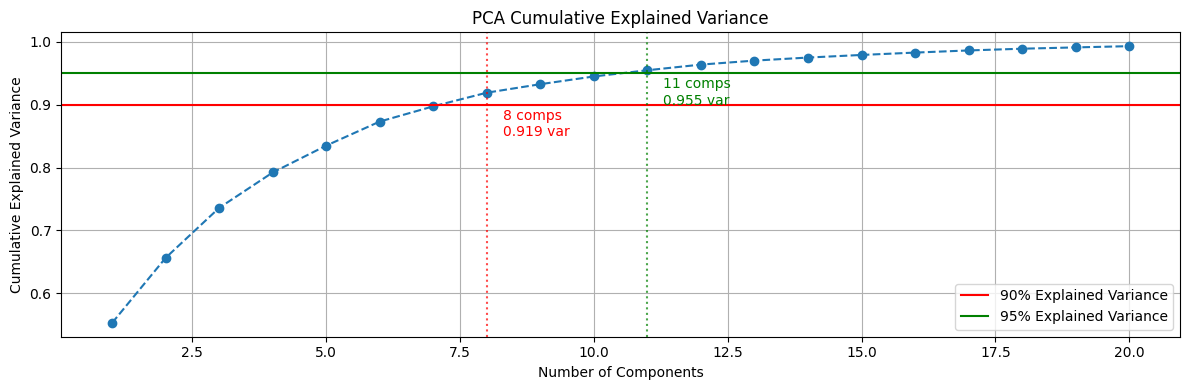

In [236]:
import matplotlib.pyplot as plt
import numpy as np

# Get the variance values from PySpark
explained_variance = pca_model.explainedVariance.toArray()
cumulative_variance = np.cumsum(explained_variance)

# Find component index where thresholds are reached
thresholds = [0.90, 0.95]
threshold_indices = [np.argmax(cumulative_variance >= t) for t in thresholds]

# Plot
plt.figure(figsize=(12, 4))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')

# Draw horizontal and vertical lines at thresholds
colors = ['r', 'g']
for idx, t in zip(threshold_indices, thresholds):
    comp_number = idx + 1
    cum_var = cumulative_variance[idx]

    # Horizontal line
    plt.axhline(y=t, color=colors[thresholds.index(t)], linestyle='-', label=f'{int(t*100)}% Explained Variance')
    # Vertical line
    plt.axvline(x=comp_number, color=colors[thresholds.index(t)], linestyle=':', alpha=0.7)
    # Annotation
    plt.text(comp_number + 0.3, t - 0.05, f'{comp_number} comps\n{cum_var:.3f} var', color=colors[thresholds.index(t)])

# Labels & Legend
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


# Doing pyspark ML 

In [178]:
from pyspark.sql.functions import lit

# Add label column (0 = Group A, 1 = Group C)
result_group_a_norm = result_group_a_norm.withColumn("label", lit(1))
result_group_c_norm = result_group_c_norm.withColumn("label", lit(0))

print("Columns in result_group_a_norm:")
print(result_group_a_norm.columns)

print("\nColumns in result_group_c_norm:")
print(result_group_c_norm.columns)


Columns in result_group_a_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']

Columns in result_group_c_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']


In [179]:
# Combine into one dataset
full_df = result_group_a_norm.union(result_group_c_norm)



In [180]:
from pyspark.sql.functions import concat_ws
from pyspark.ml.feature import VectorAssembler

# Create unique feature key for pivot
full_df = full_df.withColumn("Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand"))


In [181]:
# Get all unique feature keys
pivot_keys = [row["Electrode_WaveBand"] for row in full_df.select("Electrode_WaveBand").distinct().collect()]

# Pivot into wide format
features_df = (
    full_df.groupBy("SubjectID", "EpochID", "label")
    .pivot("Electrode_WaveBand", pivot_keys)
    .agg({"Power": "first"})
    .fillna(0.0)
)


In [182]:
features_df.count()

35793

In [183]:
feature_cols = [c for c in features_df.columns if c not in ("SubjectID", "EpochID", "label")]
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
assembled_df = assembler.transform(features_df).select("SubjectID", "EpochID", "label", "features")


In [184]:
from pyspark.ml.feature import PCA

# Try a high number first (e.g., all features)
k_max = len(feature_cols)
pca_model = PCA(k=k_max, inputCol="features", outputCol="pca_features").fit(assembled_df)

# Get explained variance and find smallest k with >= 0.95 cumulative
import numpy as np

vairance_goal = 0.95

explained_variance = np.cumsum(pca_model.explainedVariance.toArray())
k_val = np.argmax(explained_variance >= vairance_goal) + 1  # +1 because index starts at 0
print(f"Using top {k_val} components to explain {vairance_goal}% variance")

Using top 18 components to explain 0.95% variance


In [185]:
pca = PCA(k=k_val, inputCol="features", outputCol="pca_features")
pca_model = pca.fit(assembled_df)
pca_result = pca_model.transform(assembled_df)


In [267]:
pca_model

PCAModel: uid=PCA_5934db495e4e, k=20

In [186]:
from pyspark.ml.functions import vector_to_array
from pyspark.sql.functions import col

# Turn vector into individual PC columns
pca_result = pca_result.withColumn("pca_array", vector_to_array("pca_features"))

# Select label + principal components
for i in range(k_val):
    pca_result = pca_result.withColumn(f"PC{i+1}", col("pca_array")[i])

# Final dataframe with PCs
full_df = pca_result.select("SubjectID", "EpochID", "label", *[f"PC{i+1}" for i in range(k_val)])


In [187]:
from pyspark.ml.feature import VectorAssembler

pca_cols = [col for col in full_df.columns if col.startswith("PC")]
assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
assembled_df = assembler.transform(full_df).select("features", "label")

In [188]:
# Step 1: Get distinct subject IDs from each group
group_a_subjects = (
    full_df.filter(full_df["label"] == 0)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

group_c_subjects = (
    full_df.filter(full_df["label"] == 1)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

# Step 2: Get the last 3 subjects from each group for testing
test_subjects = group_a_subjects[-3:] + group_c_subjects[-3:]

# Step 3: Filter the full_df to split into train and test based on SubjectID
train_df = full_df.filter(~full_df.SubjectID.isin(test_subjects))
test_df = full_df.filter(full_df.SubjectID.isin(test_subjects))


In [189]:
test_df.head()

Row(SubjectID='sub-034', EpochID='ep-520', label=1, PC1=4.4462696372771005, PC2=-0.4380794589240463, PC3=0.2366065579297658, PC4=-0.7746612834410022, PC5=0.7535764360299452, PC6=-0.20438109796814652, PC7=-0.07599881828308457, PC8=0.3878387482227629, PC9=0.3152650799318283, PC10=-0.36795590231397735, PC11=-0.03011482245346822, PC12=-0.4527357751609812, PC13=0.1318817436234366, PC14=-0.03449561474050156, PC15=-0.12825558458008698, PC16=0.07456625526958068, PC17=-0.2567400551628786, PC18=0.16672633785346455)

In [190]:
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(inputCols=pca_cols, outputCol="features")
train_df = assembler.transform(train_df).select("features", "label")
test_df = assembler.transform(test_df).select("features", "label")

from pyspark.sql.types import IntegerType
train_df = train_df.withColumn("label", train_df["label"].cast(IntegerType()))
test_df = test_df.withColumn("label", test_df["label"].cast(IntegerType()))

In [191]:
type(train_df)

pyspark.sql.dataframe.DataFrame

In [192]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Get input size from PCA features
input_dim = len(pca_cols)

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[input_dim, 100, 2],  # input → hidden (100 units) → 2 output classes
    maxIter=1000,
    seed=42
)

mlp_model = mlp.fit(train_df)
mlp_preds = mlp_model.transform(test_df)


[Stage 22102:================================================>    (10 + 1) / 11]

In [132]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
mlp_auc = evaluator.evaluate(mlp_preds)

print("MLP AUC:", mlp_auc)

[Stage 7917:>                                                     (0 + 10) / 11]

MLP AUC: 0.7712896949295529


In [83]:
preds_pd = mlp_preds.select("prediction", "label").toPandas()

In [84]:
from sklearn.metrics import classification_report, accuracy_score

print("Neural Network accuracy:", accuracy_score(preds_pd["label"], preds_pd["prediction"]))

target_names = ["Control", "Alzheimer's"]
print(classification_report(preds_pd["label"], preds_pd["prediction"], target_names=target_names))


Neural Network accuracy: 0.7378925741121221
              precision    recall  f1-score   support

     Control       0.75      0.71      0.73      1691
 Alzheimer's       0.73      0.76      0.75      1716

    accuracy                           0.74      3407
   macro avg       0.74      0.74      0.74      3407
weighted avg       0.74      0.74      0.74      3407



# ** new ** trying with builtin functions

In [370]:
# Add label column (0 = Group A, 1 = Group C)
result_group_a_norm = result_group_a_norm.withColumn("label", lit(1))
result_group_c_norm = result_group_c_norm.withColumn("label", lit(0))

print("Columns in result_group_a_norm:")
print(result_group_a_norm.columns)

print("\nColumns in result_group_c_norm:")
print(result_group_c_norm.columns)


Columns in result_group_a_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']

Columns in result_group_c_norm:
['Electrode', 'WaveBand', 'SubjectID', 'EpochID', 'Power', 'Electrode_WaveBand', 'label']


In [371]:
# Combine into one dataset
full_df = result_group_a_norm.union(result_group_c_norm)


In [372]:
from dimensionality_reduction import prepare_features_for_pca

feature_df_func, features_cols_func = prepare_features_for_pca(full_df)

In [373]:
# checks if the yare equal , they are
feature_df_func.exceptAll(feature_df).isEmpty() and feature_df_func.exceptAll(feature_df).isEmpty()


                                                                                1]]]

True

In [374]:
from dimensionality_reduction import fit_pca_model
pca_model_func, k_95_func = fit_pca_model(feature_df_func, features_cols_func)

In [375]:
pca_model

PCAModel: uid=PCA_5934db495e4e, k=20

In [376]:
pca_model_func

PCAModel: uid=PCA_94ceb13a41a3, k=18

In [377]:
k_val

np.int64(18)

In [378]:
k_95_func

18

In [379]:
# TODO : BETWEEN THE TWO ARE TODO SECTIONS

In [356]:
# Step 1: Get distinct subject IDs from each group
group_a_subjects = (
    full_df.filter(full_df["label"] == 0)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)

group_c_subjects = (
    full_df.filter(full_df["label"] == 1)
    .select("SubjectID")
    .distinct()
    .orderBy("SubjectID")
    .rdd.map(lambda r: r[0])
    .collect()
)


In [362]:
# Step 2: Get the last 3 subjects from each group for testing
test_subjects = group_a_subjects[-3:] + group_c_subjects[-3:]

# Step 3: Filter the full_df to split into train and test based on SubjectID
full_df_train = full_df.filter(~full_df.SubjectID.isin(test_subjects))
test_df_test = full_df.filter(full_df.SubjectID.isin(test_subjects))

In [363]:
from dimensionality_reduction import prepare_features_for_pca

# TODO , NEED TO FINISH THIS AND SEE WHAT IS UP

In [365]:
full_df_train = prepare_features_for_pca(full_df_train)

In [366]:
full_df_train = apply_pca_model(full_df_train, features_cols_func, pca_model_func, k_95_func)
test_df_test = apply_pca_model(full_df_train, features_cols_func, pca_model_func, k_95_func)


AttributeError: 'tuple' object has no attribute '_jdf'

In [ ]:
# TO DO , do what did above that got good results here and see if it is repreduceable

In [387]:
 #before setting subjects for test

In [388]:
import importlib
import dimensionality_reduction

importlib.reload(dimensionality_reduction)
from dimensionality_reduction import apply_pca_model 


In [389]:
pca_model_func, k_95_func = fit_pca_model(train_df_func, features_cols_func) # notice , got feature_cols from much earlier

In [390]:
print(k_95_func)

17


In [ ]:
# after setting subjects for test

In [441]:
# Step 2: Get the last 3 subjects from each group for testing
NUM_TEST_SUBJECTS = 2 
test_subjects = group_a_subjects[-NUM_TEST_SUBJECTS:] + group_c_subjects[-NUM_TEST_SUBJECTS:]

# Step 3: Filter the full_df to split into train and test based on SubjectID
train_df_func = feature_df_func.filter(~feature_df_func.SubjectID.isin(test_subjects))
test_df_func = feature_df_func.filter(feature_df_func.SubjectID.isin(test_subjects))

In [442]:
import importlib
import dimensionality_reduction

importlib.reload(dimensionality_reduction)
from dimensionality_reduction import apply_pca_model 


In [443]:
pca_model_func, k_95_func = fit_pca_model(train_df_func, features_cols_func) # notice , got feature_cols from much earlier

In [444]:
print(train_df_func.select("SubjectID").distinct().count())
print(test_df_func.select("SubjectID").distinct().count())


61


4


In [445]:
print(k_95_func)

17


In [446]:
test_df_func.printSchema

<bound method DataFrame.printSchema of DataFrame[SubjectID: string, EpochID: string, label: int, T4_Beta: double, Fp2_Beta: double, P3_Alpha: double, O2_Alpha: double, T3_Delta: double, F7_Delta: double, F8_Beta: double, T4_Alpha: double, F3_Delta: double, P4_Theta: double, T3_Beta: double, F7_Theta: double, T5_Theta: double, P4_Alpha: double, T6_Alpha: double, Cz_Alpha: double, T5_Alpha: double, Cz_Delta: double, F4_Alpha: double, Pz_Beta: double, Fp1_Total: double, F4_Theta: double, O2_Beta: double, O1_Beta: double, Pz_Total: double, Pz_Alpha: double, Fp2_Alpha: double, O1_Delta: double, C3_Theta: double, Cz_Theta: double, T5_Total: double, C4_Alpha: double, Cz_Total: double, T4_Total: double, P3_Total: double, Fp1_Delta: double, Fz_Delta: double, Cz_Beta: double, Fz_Total: double, T6_Total: double, F8_Alpha: double, C4_Delta: double, F4_Total: double, O1_Alpha: double, F3_Beta: double, F4_Delta: double, Fp2_Total: double, P3_Beta: double, C4_Theta: double, Pz_Delta: double, P3_Delta

In [447]:
from dimensionality_reduction import apply_pca_model
pca_train_df_func = apply_pca_model(train_df_func, features_cols_func, pca_model_func, k_95_func)
pca_test_df_func = apply_pca_model(test_df_func, features_cols_func, pca_model_func, k_95_func)

In [448]:
pca_train_df_func.printSchema()

root
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = false)



In [449]:
pca_train_df_func.head()[0]

DenseVector([-11.41, 8.4136, -0.8276, 1.2788, 1.8616, 1.8622, 2.0861, -0.2786, 0.0794, 1.7732, -0.5461, 0.0002, -0.0134, -0.3657, -0.3615, -0.1063, -0.4385])

In [450]:
len([-11.3695, 0.0319, 0.0, 0.0, -0.0, -0.0, -0.0, 0.0, -0.0, 0.0, 0.0, -0.0, 0.0, -0.0, 0.0, 0.0, 0.0, 8.4534, -0.917, -0.0])

20

In [451]:
len([-11.2025, 8.4547, -2.1263, 1.2855, 1.9359, 1.7799, 2.0994, -0.4394, -0.5712, 1.5127, -0.5157, 0.5873, 0.0848, -0.404, 0.2554, 0.5306, 0.4176, 0.5525])

18

In [452]:
train_df.printSchema()

root
 |-- features: vector (nullable = true)
 |-- label: integer (nullable = false)



In [453]:
train_df.head()

Row(features=DenseVector([-11.2025, 8.4547, -2.1263, 1.2855, 1.9359, 1.7799, 2.0994, -0.4394, -0.5712, 1.5127, -0.5157, 0.5873, 0.0848, -0.404, 0.2554, 0.5306, 0.4176, 0.5525]), label=1)

In [454]:
pca_train_df_func

DataFrame[features: vector, label: int]

In [455]:
type(train_df)

pyspark.sql.dataframe.DataFrame

In [456]:
type(pca_train_df_func)

pyspark.sql.dataframe.DataFrame

In [457]:
diff = pca_train_df_func.exceptAll(train_df)

In [458]:
diff

DataFrame[features: vector, label: int]

In [459]:
# diff.count()

In [460]:
# train_df.count()

In [461]:
print(len(pca_train_df_func.select(vector_to_array("features")).first()[0]))
print(len(pca_test_df_func.select(vector_to_array("features")).first()[0]))

17


17


In [462]:
from pyspark.ml.classification import MultilayerPerceptronClassifier

# Get input size from PCA features

mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="label",
    layers=[k_95_func, 100, 2],  # input → hidden (100 units) → 2 output classes
    maxIter=1000,
    seed=42
)

mlp_model = mlp.fit(pca_train_df_func)
mlp_preds = mlp_model.transform(pca_test_df_func)

[Stage 66525:=========>                                            (2 + 9) / 11]

In [463]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(labelCol="label", rawPredictionCol="rawPrediction", metricName="areaUnderROC")
mlp_auc = evaluator.evaluate(mlp_preds)

print("MLP AUC:", mlp_auc)

MLP AUC: 0.8013422927592384


In [464]:
preds_pd = mlp_preds.select("prediction", "label").toPandas()

from sklearn.metrics import classification_report, accuracy_score

print("Neural Network accuracy:", accuracy_score(preds_pd["label"], preds_pd["prediction"]))

target_names = ["Control", "Alzheimer's"]
print(classification_report(preds_pd["label"], preds_pd["prediction"], target_names=target_names))

Neural Network accuracy: 0.7264957264957265
              precision    recall  f1-score   support

     Control       0.72      0.78      0.75      1153
 Alzheimer's       0.74      0.67      0.70      1070

    accuracy                           0.73      2223
   macro avg       0.73      0.72      0.72      2223
weighted avg       0.73      0.73      0.73      2223



# Note for Tomorrow: 
was on this chat yesterday : result_group_a_norm = result_group_a_norm.withColumn(
    "Electrode_WaveBand", concat_ws("_", "Electrode", "WaveBand")
)
 ... so need to figure this out , i pased twice , i saved, i think the save before 1:30 should be good 